# PCA — iris 자료로 따라가기

iris 꽃 자료(150 개체 × 4 변수) 에 주성분분석을 적용한다.  네 측정 변수 — 꽃받침 길이/너비, 꽃잎 길이/너비 — 가 표준화 후에 어떻게 두 주성분으로 압축되는지 한 단계 한 단계 따라간다.

이 자료는 변수들의 단위가 모두 cm 로 같지만, 분산은 변수마다 다르다 (꽃잎 길이의 분산이 꽃받침 너비의 분산보다 약 18 배 크다).  따라서 **표준화 PCA** 와 **표준화 안 한 PCA** 의 결과가 어떻게 달라지는지를 비교하기에도 좋은 자료다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

## 1. 자료 불러오기와 첫 인상

scikit-learn 의 `load_iris` 로 자료를 받아 DataFrame 으로 정리한다.

In [2]:
iris = load_iris()
X = iris.data                       # (150, 4)
y = iris.target                     # 0=setosa, 1=versicolor, 2=virginica
feature_names = iris.feature_names  # ['sepal length', 'sepal width', 'petal length', 'petal width']
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print(f'표본 수 n = {len(df)}')
print(f'변수 수 p = {X.shape[1]}')
df.head()

표본 수 n = 150
변수 수 p = 4


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# 변수별 평균·표준편차·분산
summary = df.iloc[:, :4].describe().T[['mean', 'std', 'min', 'max']]
summary['var'] = summary['std'] ** 2
summary.round(3)

,mean,std,min,max,var
sepal length (cm),5.843,0.828,4.3,7.9,0.686
sepal width (cm),3.057,0.436,2.0,4.4,0.190
petal length (cm),3.758,1.765,1.0,6.9,3.116
petal width (cm),1.199,0.762,0.1,2.5,0.581


**관찰**.  네 변수의 분산이 0.19 ~ 3.12 사이로 약 16 배 차이 난다.  단위는 모두 cm 로 같지만 분산이 달라서, 표준화 없이 PCA 를 돌리면 분산이 가장 큰 "꽃잎 길이" 가 PC1 을 지배한다.

## 2. 표준화

In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print('표준화 후 평균:', X_std.mean(axis=0).round(8))
print('표준화 후 표준편차:', X_std.std(axis=0).round(4))

표준화 후 평균: [-0. -0. -0. -0.]
표준화 후 표준편차: [1. 1. 1. 1.]


## 3. 공분산행렬 — 표준화 후이므로 사실상 상관행렬

In [5]:
Sigma = np.cov(X_std, rowvar=False)
Sigma_df = pd.DataFrame(Sigma, index=feature_names, columns=feature_names)
Sigma_df.round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.007,-0.118,0.878,0.823
sepal width (cm),-0.118,1.007,-0.431,-0.369
petal length (cm),0.878,-0.431,1.007,0.969
petal width (cm),0.823,-0.369,0.969,1.007


꽃잎 길이와 꽃잎 너비의 상관이 0.96 으로 매우 높다 — 이 두 변수가 거의 같은 정보를 두 번 말하고 있다는 뜻이다.  PCA 가 잡아낼 핵심이다.

## 4. 고유분해 — PC 방향과 분산

In [6]:
# np.linalg.eigh — 대칭 행렬용 고유분해 (오름차순 정렬)
eigvals, eigvecs = np.linalg.eigh(Sigma)
# 내림차순으로 재정렬
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print('고유값 (큰 순서):', eigvals.round(4))
print(f'분산 비율: {(eigvals / eigvals.sum() * 100).round(2)} %')
print(f'누적 비율: {(eigvals.cumsum() / eigvals.sum() * 100).round(2)} %')

고유값 (큰 순서): [2.9381 0.9202 0.1477 0.0209]
분산 비율: [72.96 22.85  3.67  0.52] %
누적 비율: [ 72.96  95.81  99.48 100.  ] %


**해석**.  PC1 이 전체 분산의 약 73%, PC2 가 22.9% 를 설명한다.  두 개만으로 96% 의 정보가 보존된다.  4 차원 자료를 2 차원으로 줄여도 거의 모든 변동이 살아남는다는 뜻이다.

In [7]:
loadings = pd.DataFrame(eigvecs, index=feature_names,
                        columns=[f'PC{i+1}' for i in range(4)])
loadings.round(3)

,PC1,PC2,PC3,PC4
sepal length (cm),-0.521,0.377,0.720,0.261
sepal width (cm),0.269,0.923,-0.244,-0.124
petal length (cm),-0.580,0.024,-0.142,-0.801
petal width (cm),-0.565,0.067,-0.634,0.524


**PC1 로딩 해석**.  PC1 의 로딩 (0.52, −0.27, 0.58, 0.56) 을 보면 — 꽃받침 길이·꽃잎 길이·꽃잎 너비 세 변수가 비슷한 양수 부호와 크기를 가진다.  즉 PC1 은 "꽃 전체의 크기" 축이다.  꽃받침 너비만 음수인데, 이는 꽃받침 너비가 다른 세 변수와 약간 다른 패턴을 가진다는 뜻이다.

**PC2 로딩 해석**.  PC2 는 꽃받침 너비(0.92) 가 압도적으로 크다.  PC1 이 "전체 크기" 라면, PC2 는 "꽃받침 너비의 추가 변동" 을 담당한다.

## 5. sklearn 의 PCA 와 결과 비교

In [8]:
pca = PCA(n_components=4)
Z = pca.fit_transform(X_std)

print('sklearn 의 고유값(설명 분산):', pca.explained_variance_.round(4))
print('sklearn 의 분산 비율:', (pca.explained_variance_ratio_ * 100).round(2), '%')

# 손으로 구한 고유분해와 거의 같음 (부호는 다를 수 있음)
print('\n손으로 구한 고유값:', eigvals.round(4))

sklearn 의 고유값(설명 분산): [2.9381 0.9202 0.1477 0.0209]
sklearn 의 분산 비율: [72.96 22.85  3.67  0.52] %

손으로 구한 고유값: [2.9381 0.9202 0.1477 0.0209]


## 6. PC1-PC2 평면에 시각화

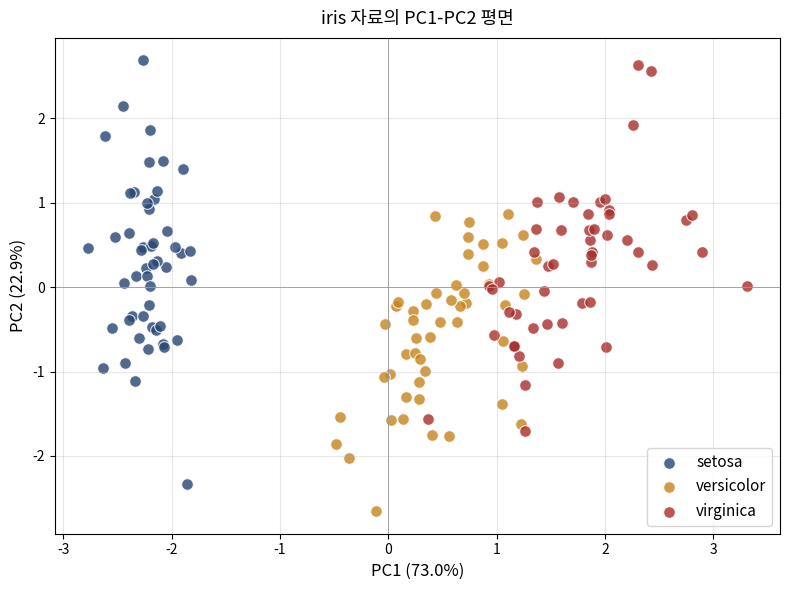

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#274472', '#C6841B', '#A52E2A']
for i, name in enumerate(target_names):
    mask = (y == i)
    ax.scatter(Z[mask, 0], Z[mask, 1], s=70, color=colors[i],
               edgecolor='white', linewidth=0.8, alpha=0.8, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('iris 자료의 PC1-PC2 평면', fontsize=13, pad=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='#999', lw=0.6)
ax.axvline(0, color='#999', lw=0.6)
plt.tight_layout()
plt.show()

**결과 해석**.  PC1 한 축만으로 setosa 가 다른 두 종(versicolor, virginica) 과 거의 완벽히 분리된다.  versicolor 와 virginica 사이의 분리는 PC1 만 가지고는 약간 겹치지만, PC1-PC2 평면 전체로 보면 충분히 구분된다.  4 차원 자료를 2 차원으로 줄였는데 세 품종의 구조가 그대로 유지된다 — 이것이 PCA 의 핵심 약속이다.

## 7. Scree plot — 주성분 개수 정하기

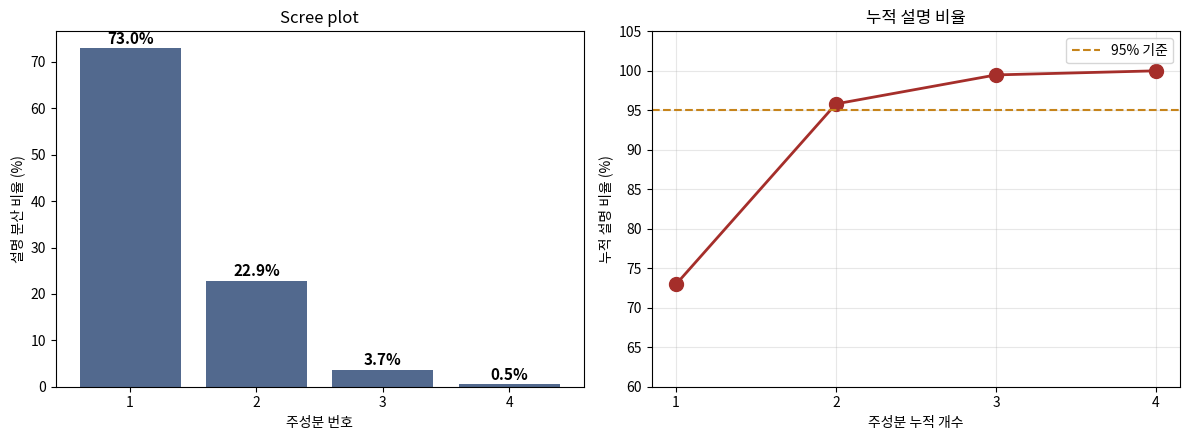

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
x_pos = np.arange(1, 5)

ax1.bar(x_pos, pca.explained_variance_ratio_ * 100,
        color='#274472', alpha=0.8)
ax1.set_xlabel('주성분 번호')
ax1.set_ylabel('설명 분산 비율 (%)')
ax1.set_title('Scree plot')
ax1.set_xticks(x_pos)
for i, v in enumerate(pca.explained_variance_ratio_):
    ax1.text(x_pos[i], v*100 + 1, f'{v*100:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax2.plot(x_pos, pca.explained_variance_ratio_.cumsum() * 100,
         'o-', color='#A52E2A', lw=2, markersize=10)
ax2.axhline(95, color='#C6841B', ls='--', lw=1.5, label='95% 기준')
ax2.set_xlabel('주성분 누적 개수')
ax2.set_ylabel('누적 설명 비율 (%)')
ax2.set_title('누적 설명 비율')
ax2.set_xticks(x_pos)
ax2.set_ylim(60, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**결과 해석**.  PC1 + PC2 의 누적 설명 비율이 95.8% — 95% 기준선을 넘는다.  따라서 차원 축소 시 두 주성분만 남기는 것이 합리적이다.  3, 4 번째 주성분은 합쳐서 4% 정도의 자투리 변동만 담고 있어 버려도 정보 손실이 미미하다.

## 8. 정리

1. 4 변수, 150 표본의 iris 자료를 표준화한 뒤 PCA 를 적용.
2. PC1 이 73% , PC2 가 23% 의 분산을 설명 — 두 주성분으로 96% 의 정보가 보존됨.
3. PC1 은 "꽃 전체의 크기" 축, PC2 는 "꽃받침 너비" 축으로 해석.
4. 4 차원을 2 차원으로 줄였지만 세 품종의 분리 구조가 그대로 유지됨.